# Computational Complexity Benchmark

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import scienceplots
import seaborn as sns

In [2]:
mpl.rcParams["text.usetex"] = False  # Disable LaTeX rendering
plt.style.use(["science", "ieee", "no-latex"])  # Use 'no-latex' for compatibility

In [3]:
mpl.rcParams.update({
    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 6,
})

## Load results

In [4]:
BASE_DIR = Path("..") / "results" / "03_Extracted_Features_Aggregated_Files"

In [5]:
df_bosch_cnc = pd.read_csv(BASE_DIR / "Bosch_CNC.csv", sep=";", decimal=",")
df_bosch_cnc["dataset"] = "Bosch CNC"
df_bosch_cnc["sampling_frequency"] = 2000
df_bosch_cnc["num_samples"] = 1700
df_bosch_cnc["num_channels"] = 3

df_turning = pd.read_csv(BASE_DIR / "Turning_Dataset.csv", sep=";", decimal=",")
df_turning["dataset"] = "Turning Dataset"
df_turning["sampling_frequency"] = 10000
df_turning["num_samples"] = 808
df_turning["num_channels"] = 1

df_cmohs = pd.read_csv(BASE_DIR / "Condition_Monitoring_of_Hydraulic_Systems.csv", sep=";", decimal=",")
df_cmohs["dataset"] = "Condition Monitoring of Hydraulic Systems"
df_cmohs["sampling_frequency"] = 100
df_cmohs["num_samples"] = 2205
df_cmohs["num_channels"] = 17

df_cnc_mill = pd.read_csv(BASE_DIR / "CNC_Mill_Tool_Wear.csv", sep=";", decimal=",")
df_cnc_mill["dataset"] = "CNC Mill Tool Wear"
df_cnc_mill["sampling_frequency"] = 10
df_cnc_mill["num_samples"] = 18
df_cnc_mill["num_channels"] = 47

In [6]:
# Combine all results into one dataframe
df_all = pd.concat([df_bosch_cnc, df_turning, df_cmohs, df_cnc_mill], axis="index", ignore_index=True)

# Replace NaN values with 0
df_all = df_all.fillna("")

df_all["package_name"] = df_all["package"] + "_" + df_all["configuration"]

## Visualize computational complexity

In [7]:
df_all["computational_complexity"] = df_all["average_cpu_load"] * df_all["execution_time"]

In [8]:
palette = sns.color_palette("Set1", n_colors=df_all["package"].nunique())
palette = {pkg: palette[i] for i, pkg in enumerate(sorted(df_all["package"].unique()))}

# Define unique hatches for each package
hatches = ['/', '\\', '-', '//', '\\\\', 'x', 'o', 'O', '.', '*']
hatch_dict = {pkg: hatches[i % len(hatches)] for i, pkg in enumerate(sorted(df_all["package"].unique()))}

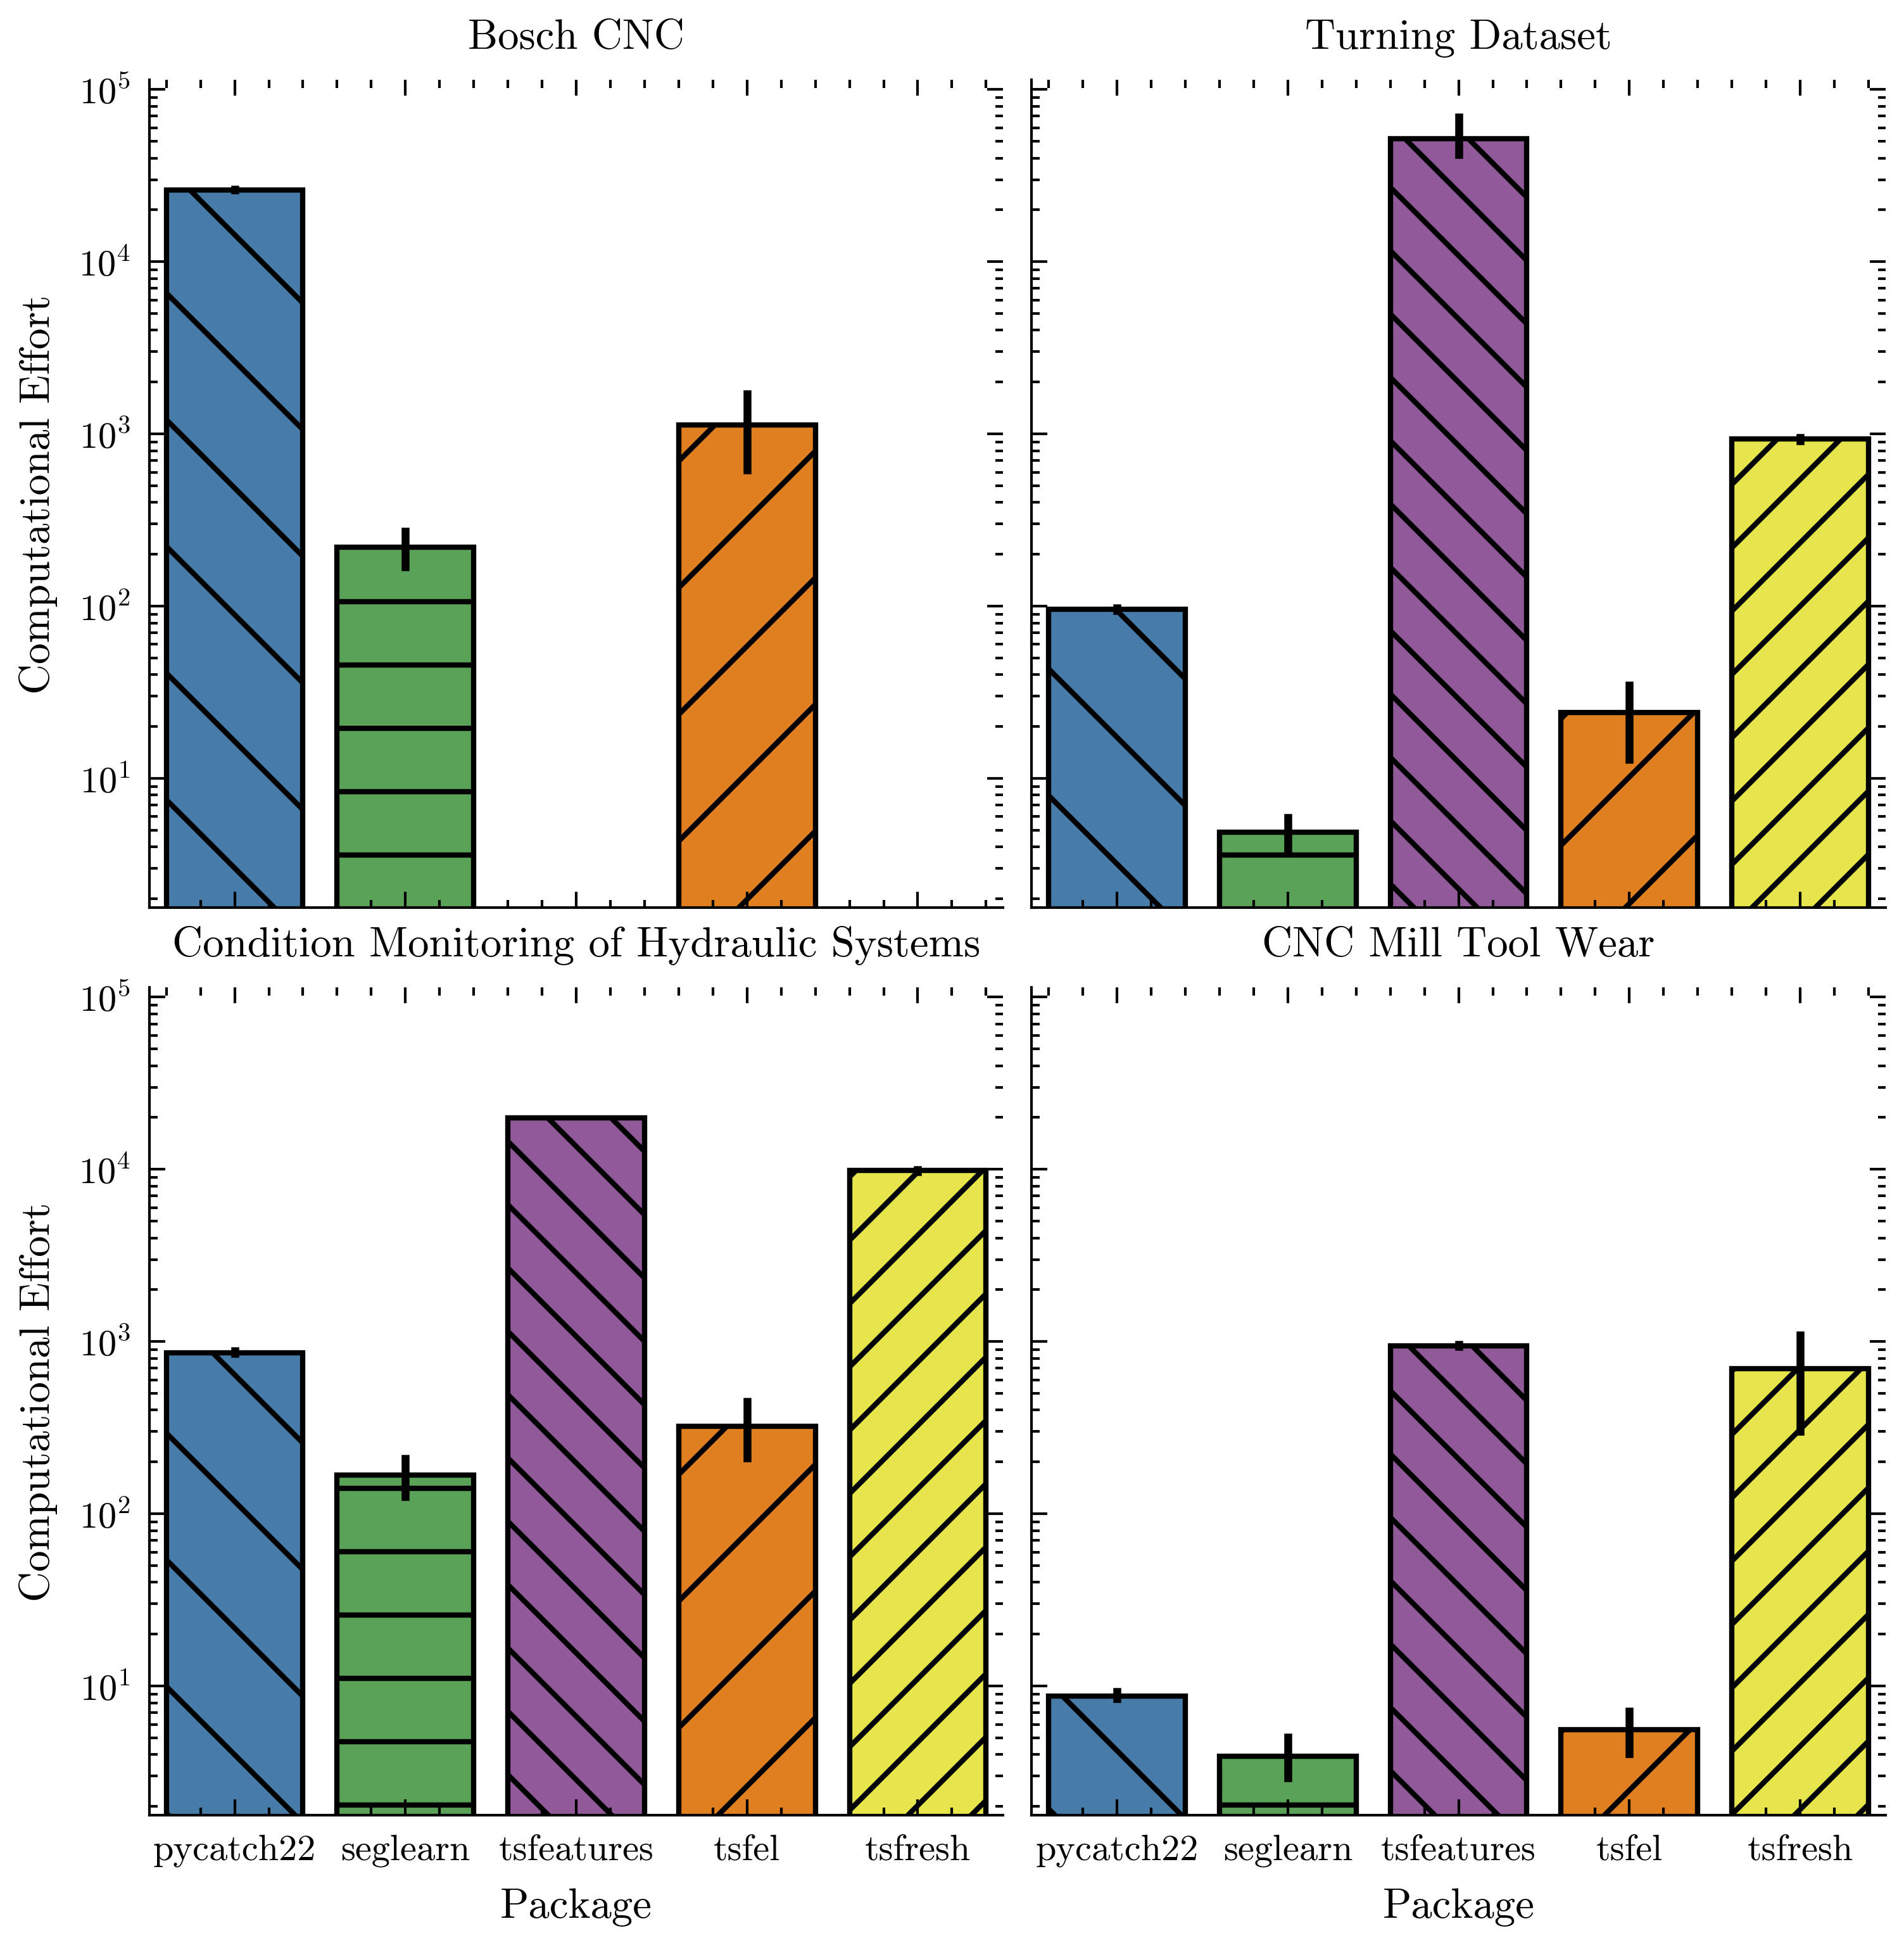

In [9]:
df_plot = df_all[~df_all["package_name"].str.contains("60|kats")] # Single processing packages

g = sns.catplot(
    data=df_plot,
    x="package",
    y="computational_complexity",
    col="dataset",
    kind="bar",
    hue="package",
    height=4,
    aspect=1,
    col_wrap=2,
    edgecolor="black",
    err_kws={'color': 'black', "linestyle": "-"},
    palette=palette,
    order=sorted(df_plot["package"].unique()),
)
g.set_axis_labels("Package", "Computational Effort")
g.set_titles("{col_name}")

# Add hatches to the bars
hatches = ['/', '\\', '-', '//', '\\\\', 'x', 'o', 'O', '.', '*']
for ax in g.axes.flat:
    for i, bar in enumerate(ax.patches):
        bar.set_hatch(hatches[i])

g.figure.set_size_inches(5.0, 5.0)  # Adjust figure size for better layout

plt.yscale("log")
plt.savefig("computational_effort_single_processing.png", dpi=600, bbox_inches="tight")
plt.savefig("computational_effort_single_processing.pdf", bbox_inches="tight")

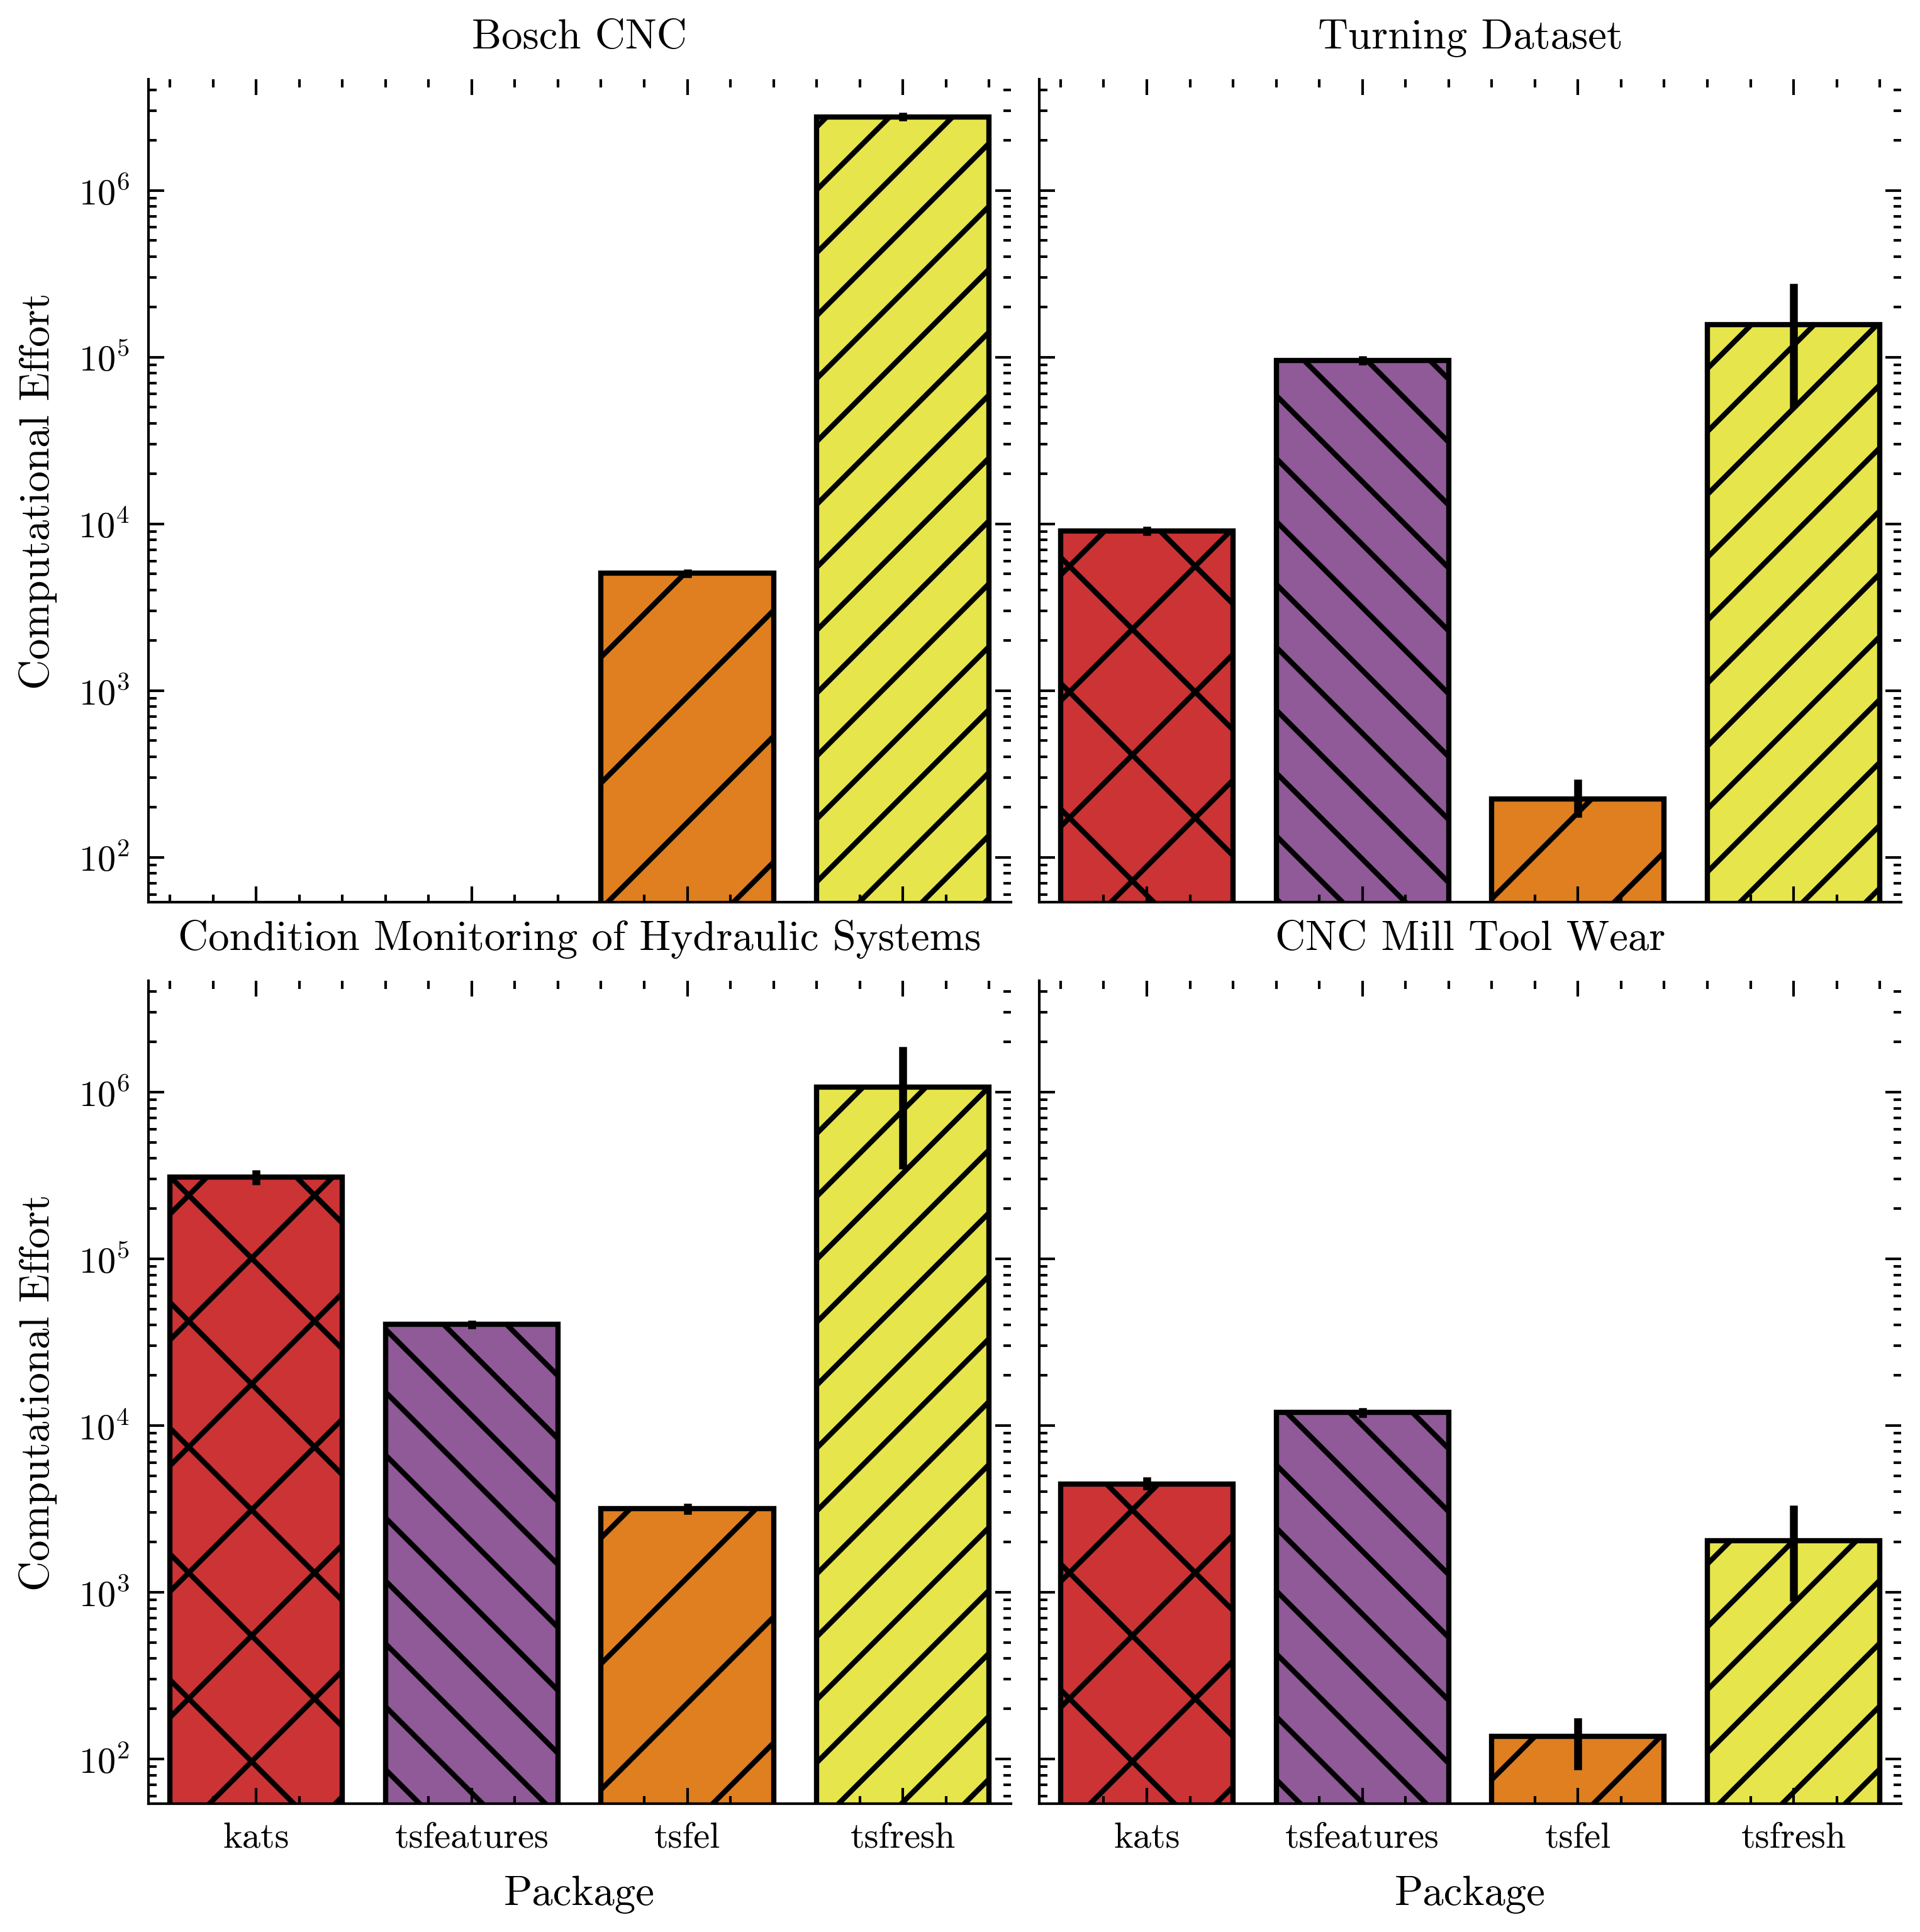

In [10]:
df_plot = df_all[df_all["package_name"].str.contains("60|kats")] # Multiprocessing packages

g = sns.catplot(
    data=df_plot,
    x="package",
    y="computational_complexity",
    col="dataset",
    kind="bar",
    hue="package",
    height=4,
    aspect=1,
    col_wrap=2,
    edgecolor="black",
    err_kws={'color': 'black', "linestyle": "-"},
    palette=palette,
    order=sorted(df_plot["package"].unique()),
)
g.set_axis_labels("Package", "Computational Effort")
g.set_titles("{col_name}")

# Add hatches to the bars
hatches = ['//', '/', '\\\\', 'x']
for ax in g.axes.flat:
    for i, bar in enumerate(ax.patches):
        bar.set_hatch(hatches[i])

g.figure.set_size_inches(5.0, 5.0)  # Adjust figure size for better layout

plt.yscale("log")
plt.savefig("computational_effort_multiprocessing.png", dpi=600, bbox_inches="tight")
plt.savefig("computational_effort_multiprocessing.pdf", bbox_inches="tight")

## Peak memory

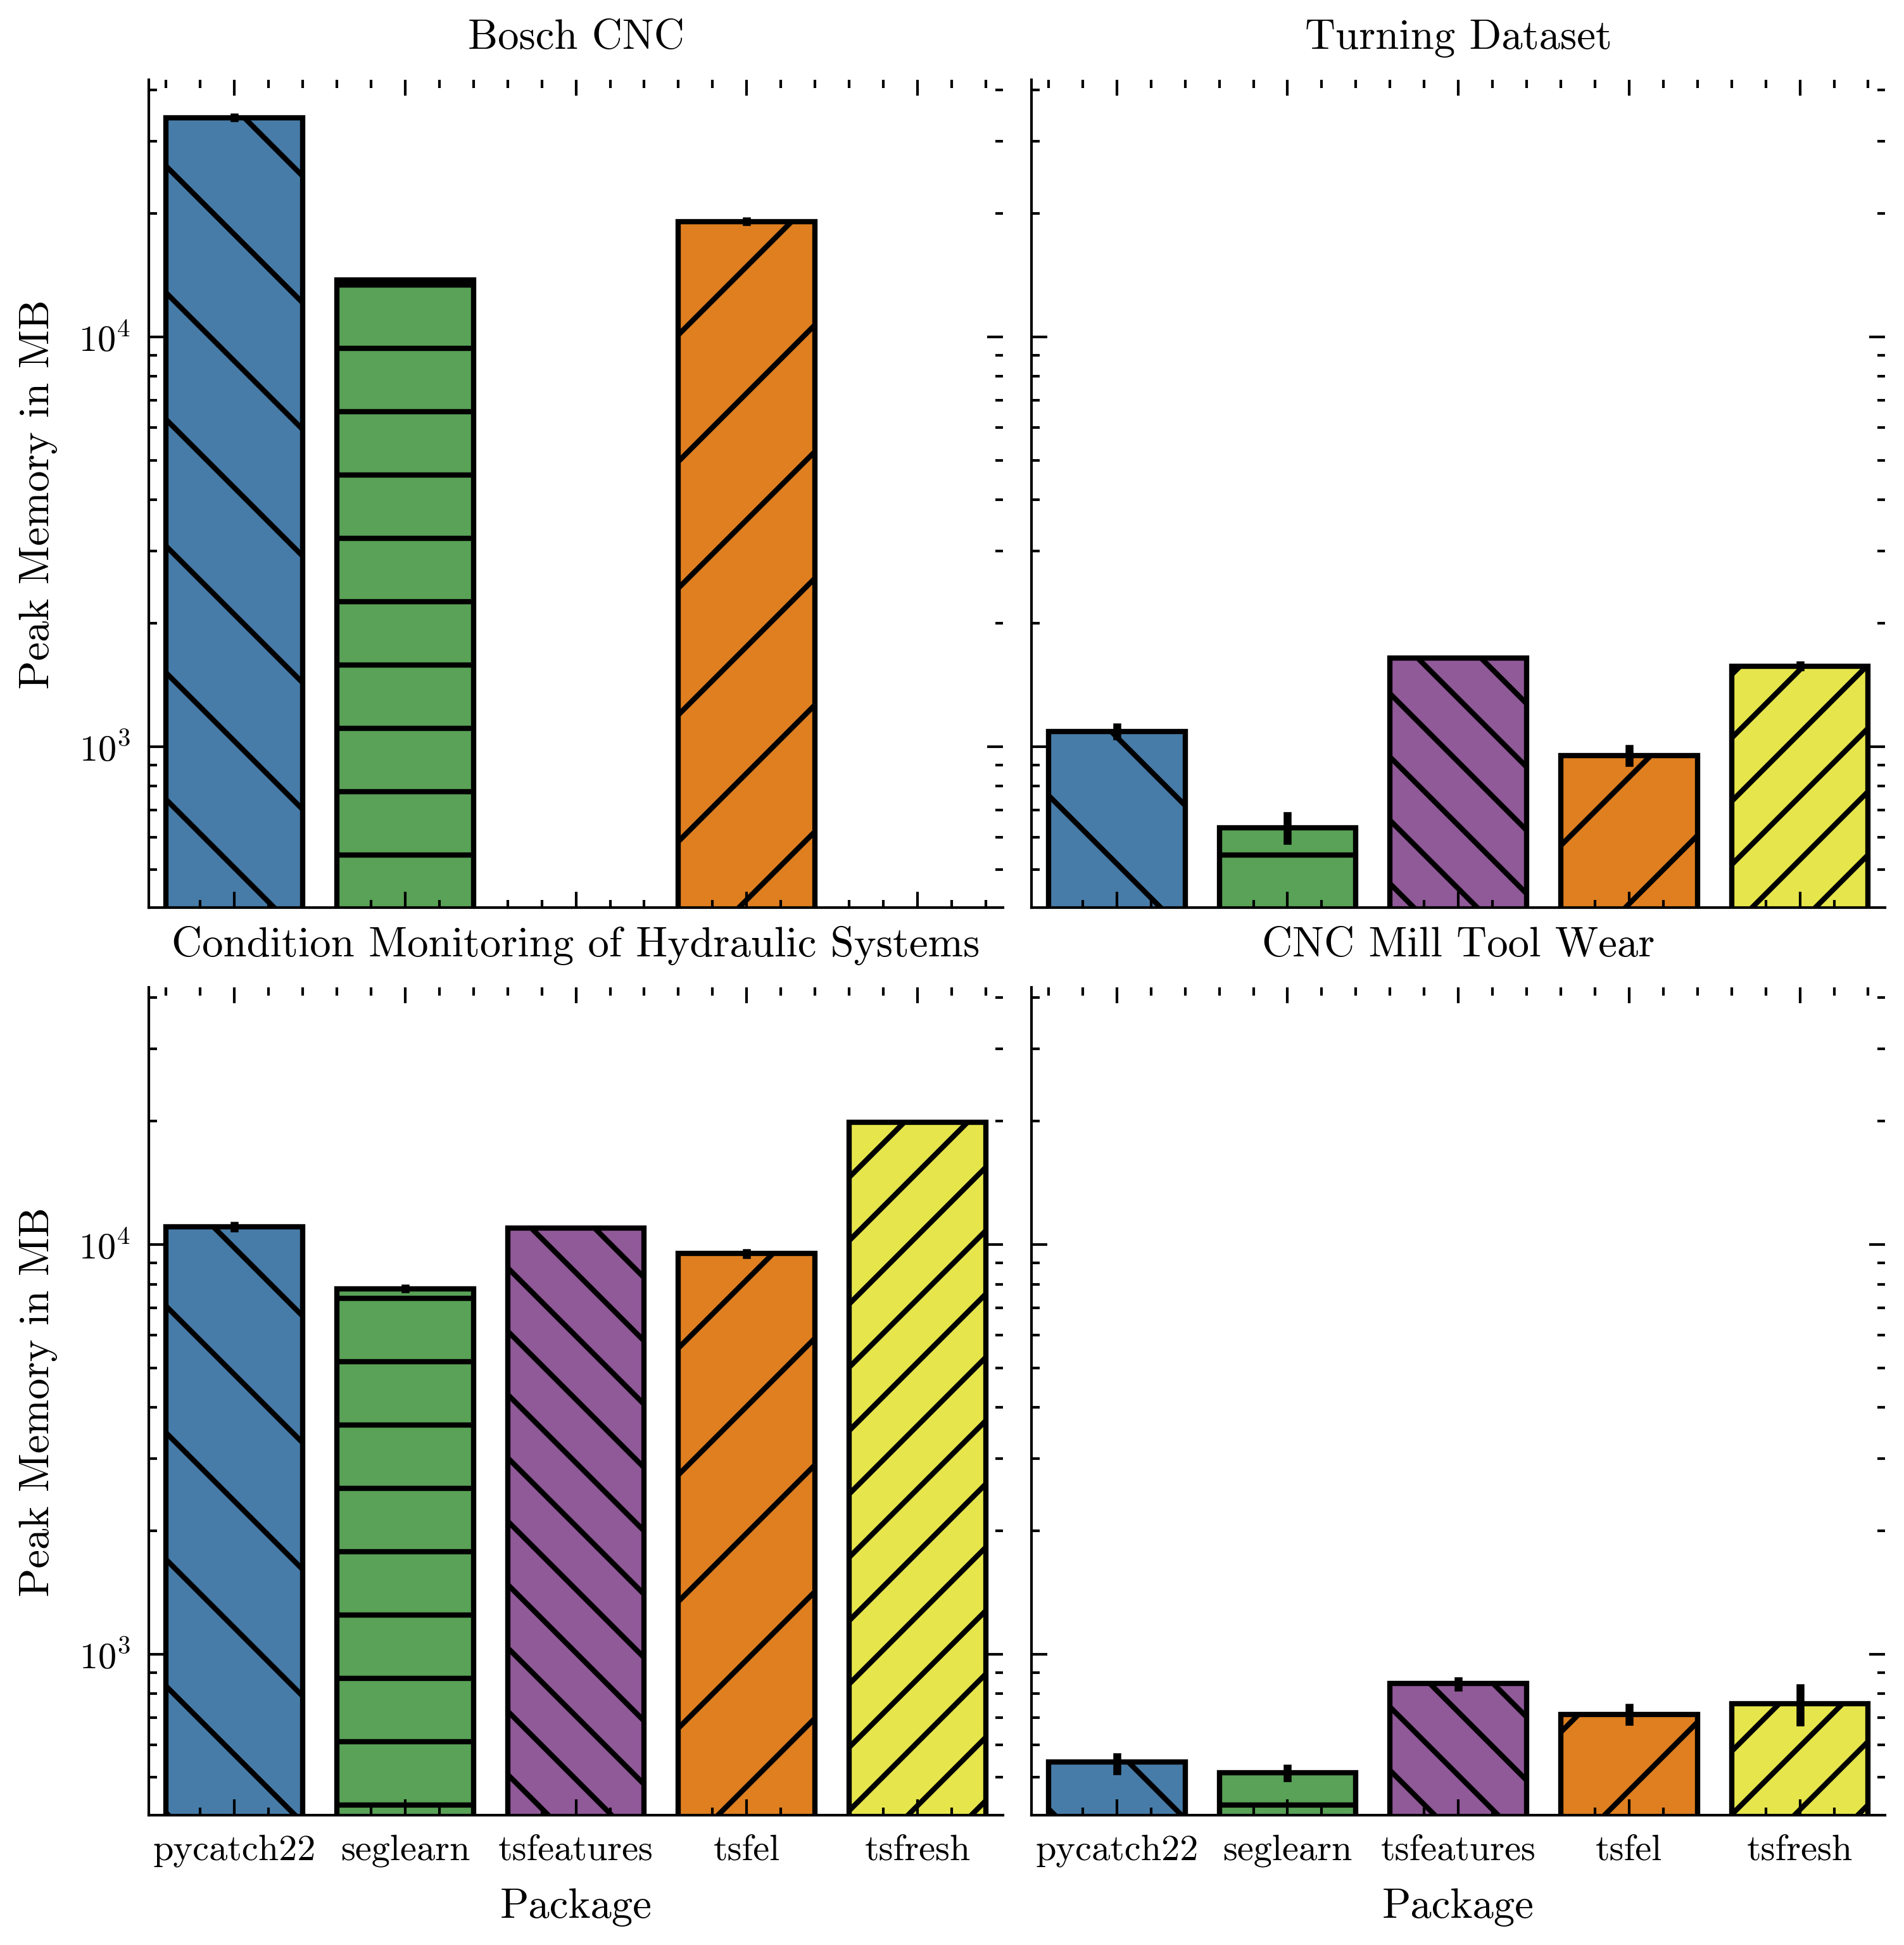

In [11]:
df_plot = df_all[~df_all["package_name"].str.contains("60|kats")] # Single processing packages

g = sns.catplot(
    data=df_plot,
    x="package",
    y="peak_memory",
    col="dataset",
    kind="bar",
    hue="package",
    height=4,
    aspect=1,
    col_wrap=2,
    edgecolor="black",
    err_kws={'color': 'black', "linestyle": "-"},
    palette=palette,
    order=sorted(df_plot["package"].unique()),
)
g.set_axis_labels("Package", "Peak Memory in MB")
g.set_titles("{col_name}")

# Add hatches to the bars
hatches = ['/', '\\', '-', '//', '\\\\', 'x', 'o', 'O', '.', '*']
for ax in g.axes.flat:
    for i, bar in enumerate(ax.patches):
        bar.set_hatch(hatches[i])

g.figure.set_size_inches(5.0, 5.0)  # Adjust figure size for better layout

plt.yscale("log")
plt.savefig("peak_memory_single_processing.png", dpi=600, bbox_inches="tight")
plt.savefig("peak_memory_single_processing.pdf", bbox_inches="tight")

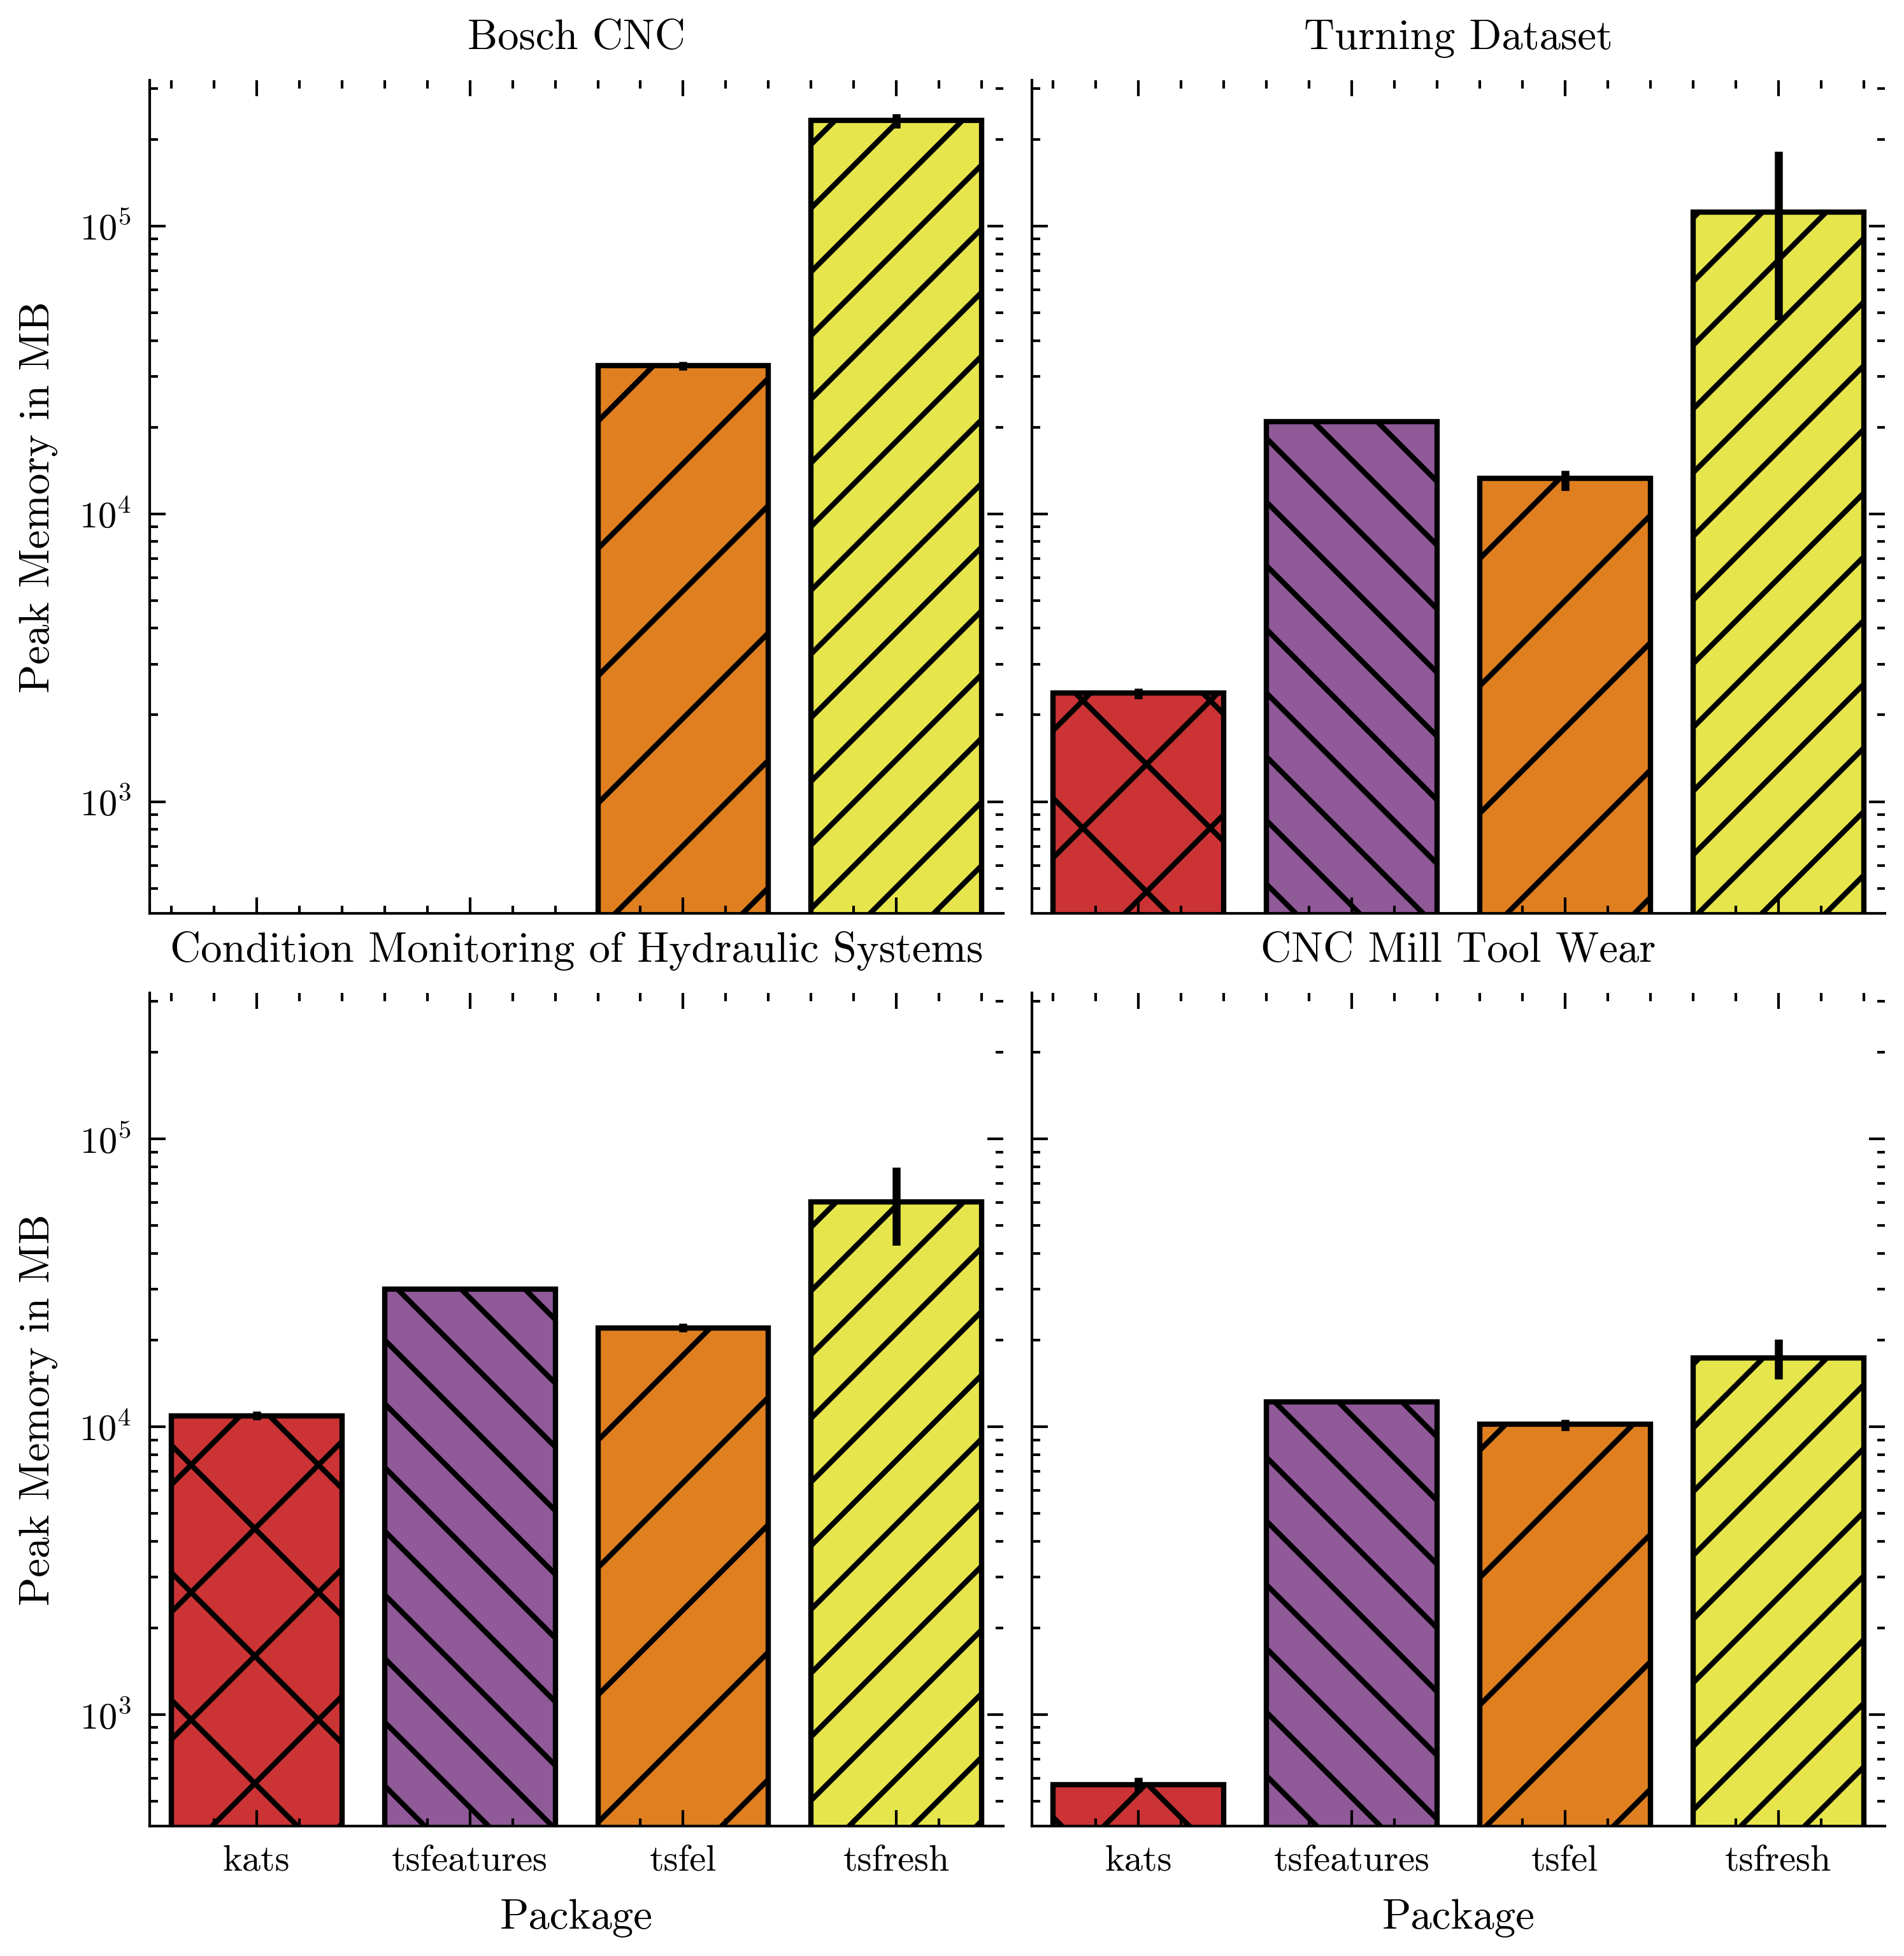

In [12]:
df_plot = df_all[df_all["package_name"].str.contains("60|kats")] # Multiprocessing packages

g = sns.catplot(
    data=df_plot,
    x="package",
    y="peak_memory",
    col="dataset",
    kind="bar",
    hue="package",
    height=4,
    aspect=1,
    col_wrap=2,
    edgecolor="black",
    err_kws={'color': 'black', "linestyle": "-"},
    palette=palette,
    order=sorted(df_plot["package"].unique()),
)
g.set_axis_labels("Package", "Peak Memory in MB")
g.set_titles("{col_name}")

# Add hatches to the bars
hatches = ['//', '/', '\\\\', 'x']
for ax in g.axes.flat:
    for i, bar in enumerate(ax.patches):
        bar.set_hatch(hatches[i])

g.figure.set_size_inches(5.0, 5.0)  # Adjust figure size for better layout

plt.yscale("log")
plt.savefig("peak_memory_multiprocessing.png", dpi=600, bbox_inches="tight")
plt.savefig("peak_memory_multiprocessing.pdf", bbox_inches="tight")

## Computational complexity per feature + number of extracted features

C:\Users\csr\AppData\Local\Temp\ipykernel_101204\4207037877.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\csr\AppData\Local\Temp\ipykernel_101204\4207037877.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\csr\AppData\Local\Temp\ipykernel_101204\4207037877.py:91: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\csr\AppData\Local\Temp\ipykernel_101204\4207037877.py:120: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue`

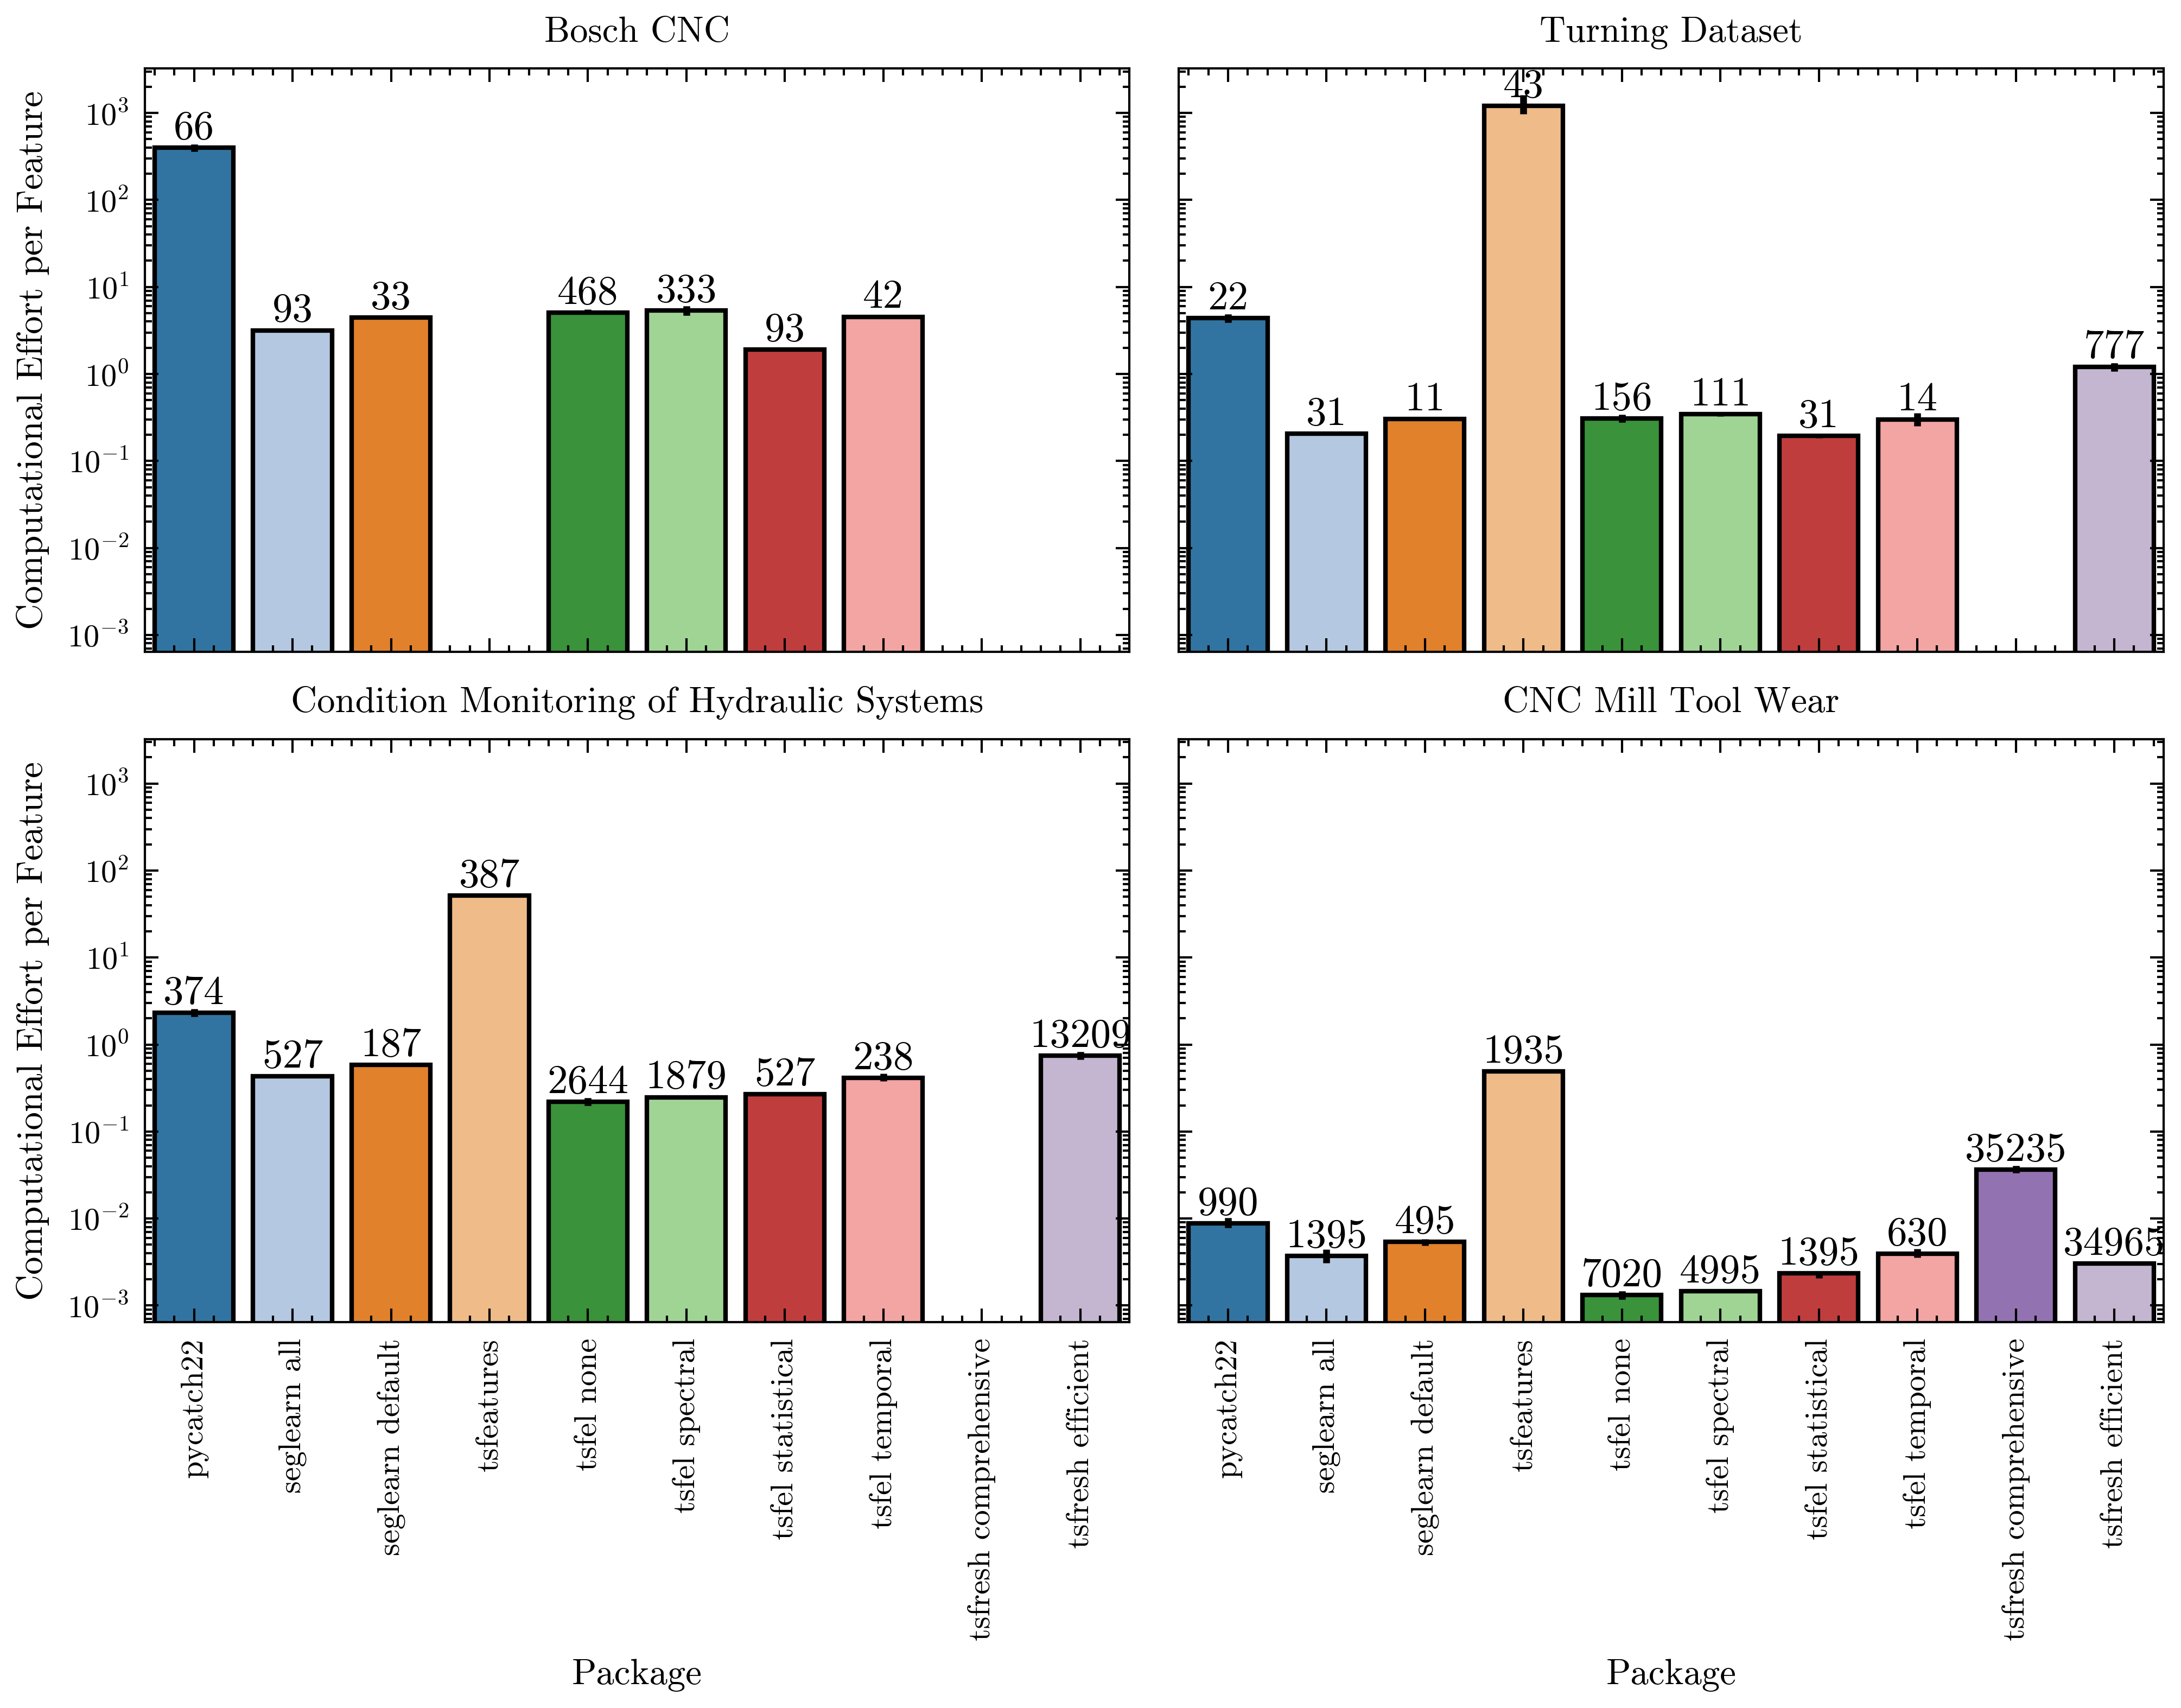

In [17]:
df_plot = df_all[~df_all["package_name"].str.contains("60|kats")].copy() # Single processing packages
df_plot["computational_complexity_per_num_features"] = df_plot["computational_complexity"] / df_plot["extracted_features"]


# Rename packages for better visualization
df_plot.loc[df_plot["package_name"].str.contains("pycatch22_catch24=False"), "package_name"] = "pycatch22"
df_plot.loc[df_plot["package_name"].str.contains("tsfel_domain=none, n_jobs=1"), "package_name"] = "tsfel none"
df_plot.loc[df_plot["package_name"].str.contains("tsfel_domain=statistical, n_jobs=1"), "package_name"] = "tsfel statistical"
df_plot.loc[df_plot["package_name"].str.contains("tsfel_domain=temporal, n_jobs=1"), "package_name"] = "tsfel temporal"
df_plot.loc[df_plot["package_name"].str.contains("tsfel_domain=spectral, n_jobs=1"), "package_name"] = "tsfel spectral"
df_plot.loc[df_plot["package_name"].str.contains("seglearn_features_to_extract=default"), "package_name"] = "seglearn default"
df_plot.loc[df_plot["package_name"].str.contains("seglearn_features_to_extract=all"), "package_name"] = "seglearn all"
df_plot.loc[df_plot["package_name"].str.contains("tsfresh_fc_params=efficient, n_jobs=0"), "package_name"] = "tsfresh efficient"
df_plot.loc[df_plot["package_name"].str.contains("tsfresh_fc_params=comprehensive, n_jobs=0"), "package_name"] = "tsfresh comprehensive"
df_plot.loc[df_plot["package_name"].str.contains("tsfeatures_threads=1"), "package_name"] = "tsfeatures"


# Globale Reihenfolge und Palette definieren
all_packages = sorted(df_plot["package_name"].unique())
global_palette = sns.color_palette("tab20", n_colors=len(all_packages))

# Mapping von package_name -> Farbe erstellen
palette_dict = {
    pkg: color for pkg, color in zip(all_packages, global_palette)
}

fig, ax = plt.subplots(figsize=(10, 6), nrows=2, ncols=2, sharex=True, sharey=True)

# --- Bosch CNC ---

sub = df_plot[df_plot["dataset"] == "Bosch CNC"].copy()
order = all_packages  # globale Reihenfolge verwenden
sns.barplot(
    data=sub,
    x="package_name",
    y="computational_complexity_per_num_features",
    edgecolor="black",
    err_kws={'color': 'black'},
    order=order,
    ax=ax[0, 0],
    palette=palette_dict,   # konsistente Palette
)
features_per_pkg = (
    sub.groupby("package_name")["extracted_features"]
       .first()
       .reindex(order)
)
for bar, feats in zip(ax[0, 0].patches, features_per_pkg.dropna()):
    ax[0, 0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + (bar.get_height() * 0.02),
        f"{int(feats)}",
        ha="center",
        va="bottom",
        fontsize=9,
        clip_on=False,
    )

# --- Turning Dataset ---

sub = df_plot[df_plot["dataset"] == "Turning Dataset"].copy()
sns.barplot(
    data=sub,
    x="package_name",
    y="computational_complexity_per_num_features",
    edgecolor="black",
    err_kws={'color': 'black'},
    order=order,
    ax=ax[0, 1],
    palette=palette_dict,
)
features_per_pkg = (
    sub.groupby("package_name")["extracted_features"]
       .first()
       .reindex(order)
)
for bar, feats in zip(ax[0, 1].patches, features_per_pkg.dropna()):
    ax[0, 1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + (bar.get_height() * 0.02),
        f"{int(feats)}",
        ha="center",
        va="bottom",
        fontsize=9,
        clip_on=False,
    )

# --- Condition Monitoring of Hydraulic Systems ---

sub = df_plot[df_plot["dataset"] == "Condition Monitoring of Hydraulic Systems"].copy()
sns.barplot(
    data=sub,
    x="package_name",
    y="computational_complexity_per_num_features",
    edgecolor="black",
    err_kws={'color': 'black'},
    order=order,
    ax=ax[1, 0],
    palette=palette_dict,
)
features_per_pkg = (
    sub.groupby("package_name")["extracted_features"]
       .first()
       .reindex(order)
)
for bar, feats in zip(ax[1, 0].patches, features_per_pkg.dropna()):
    ax[1, 0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + (bar.get_height() * 0.02),
        f"{int(feats)}",
        ha="center",
        va="bottom",
        fontsize=9,
        clip_on=False,
    )

# --- CNC Mill Tool Wear ---

sub = df_plot[df_plot["dataset"] == "CNC Mill Tool Wear"].copy()
sns.barplot(
    data=sub,
    x="package_name",
    y="computational_complexity_per_num_features",
    edgecolor="black",
    err_kws={'color': 'black'},
    order=order,
    ax=ax[1, 1],
    palette=palette_dict,
)
features_per_pkg = (
    sub.groupby("package_name")["extracted_features"]
       .first()
       .reindex(order)
)
for bar, feats in zip(ax[1, 1].patches, features_per_pkg.dropna()):
    ax[1, 1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + (bar.get_height() * 0.02),
        f"{int(feats)}",
        ha="center",
        va="bottom",
        fontsize=9,
        clip_on=False,
    )

# Rotate x-axis labels for better readability
for axes in ax.flat:
    for label in axes.get_xticklabels():
        label.set_rotation(90)
        label.set_ha('center')

ax[0, 0].set_title("Bosch CNC")
ax[0, 1].set_title("Turning Dataset")
ax[1, 0].set_title("Condition Monitoring of Hydraulic Systems")
ax[1, 1].set_title("CNC Mill Tool Wear")
ax[1, 0].set_xlabel("Package")
ax[1, 1].set_xlabel("Package")
ax[0, 0].set_ylabel("Computational Effort per Feature")
ax[1, 0].set_ylabel("Computational Effort per Feature")

# Set width and height of the figure to 5 inches
fig.set_size_inches(8, 5)

# Reduce whitespace between subplots
plt.subplots_adjust(wspace=0.05, hspace=0.15)

plt.yscale("log")
plt.savefig("computational_effort_single_processing_per_feature.png", dpi=600, bbox_inches="tight")
plt.savefig("computational_effort_single_processing_per_feature.pdf", bbox_inches="tight")
plt.savefig("computational_effort_single_processing_per_feature.svg", bbox_inches="tight")

C:\Users\csr\AppData\Local\Temp\ipykernel_101204\2108065016.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\csr\AppData\Local\Temp\ipykernel_101204\2108065016.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\csr\AppData\Local\Temp\ipykernel_101204\2108065016.py:86: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\csr\AppData\Local\Temp\ipykernel_101204\2108065016.py:116: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue`

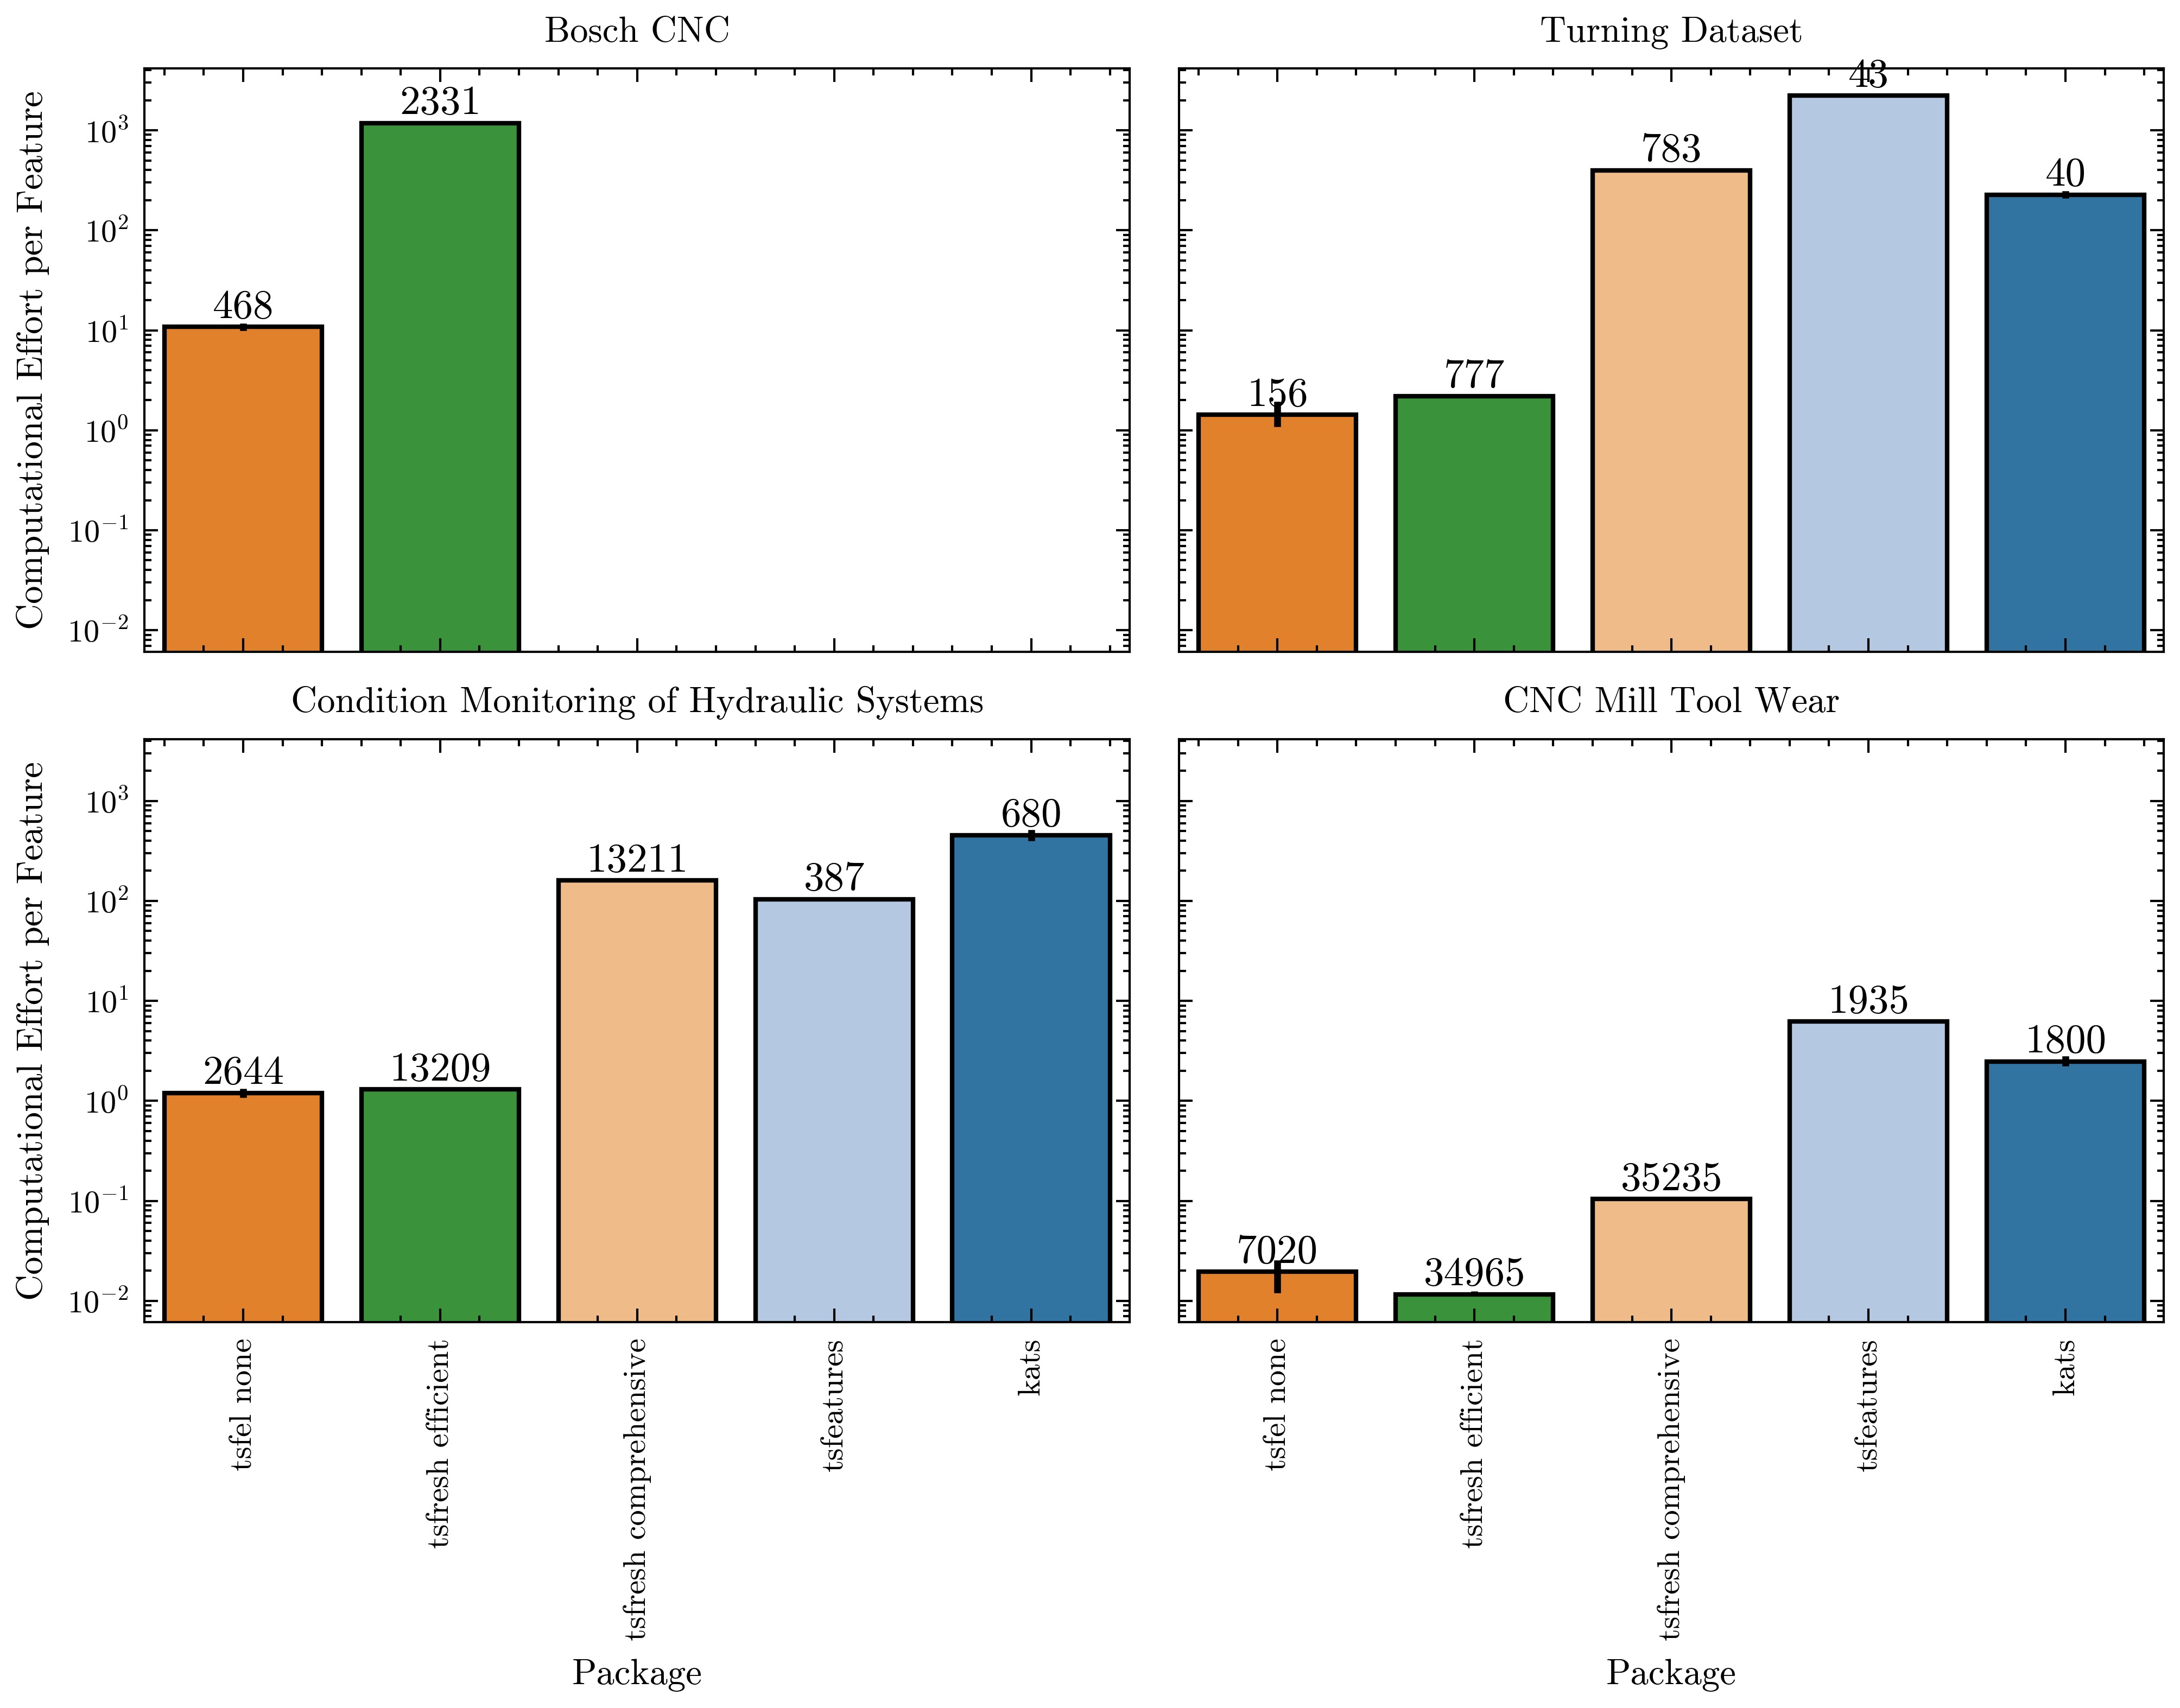

In [18]:
df_plot = df_all[df_all["package_name"].str.contains("60|kats")].copy() # Multiprocessing packages
df_plot["computational_complexity_per_num_features"] = df_plot["computational_complexity"] / df_plot["extracted_features"]

fig, ax = plt.subplots(figsize=(10, 6), nrows=2, ncols=2, sharex=True, sharey=True)

# Rename packages for better visualization
df_plot.loc[df_plot["package_name"].str.contains("tsfel_domain=none, n_jobs=60"), "package_name"] = "tsfel none"
df_plot.loc[df_plot["package_name"].str.contains("tsfresh_fc_params=efficient, n_jobs=60"), "package_name"] = "tsfresh efficient"
df_plot.loc[df_plot["package_name"].str.contains("tsfresh_fc_params=comprehensive, n_jobs=60"), "package_name"] = "tsfresh comprehensive"
df_plot.loc[df_plot["package_name"].str.contains("tsfeatures_threads=60"), "package_name"] = "tsfeatures"
df_plot.loc[df_plot["package_name"].str.contains("kats_"), "package_name"] = "kats"

package_order = ["tsfel none", "tsfresh efficient", "tsfresh comprehensive", "tsfeatures", "kats"]

# Define palette
all_packages = sorted(df_plot["package_name"].unique())
global_palette = sns.color_palette("tab20", n_colors=len(all_packages))
palette_dict = dict(zip(all_packages, global_palette))

# Add Bosch CNC plot
sub = df_plot[df_plot["dataset"] == "Bosch CNC"].copy()
# order = sorted(sub["package_name"].unique())
order = [p for p in package_order if p in sub["package_name"].unique()]

sns.barplot(
    data=sub,
    x="package_name",
    y="computational_complexity_per_num_features",
    edgecolor="black",
    err_kws={'color': 'black'},
    order=order,
    ax=ax[0, 0],
    # palette=sns.color_palette("tab20", n_colors=len(order)),  # or your custom palette
    palette=palette_dict,
)
features_per_pkg = (
    sub.groupby("package_name")["extracted_features"]
       .first()  # or .mean(), .sum() as needed
       .reindex(order)
)
for bar, feats in zip(ax[0, 0].patches, features_per_pkg):
    ax[0, 0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + (bar.get_height() * 0.02),
        f"{int(feats)}",
        ha="center",
        va="bottom",
        fontsize=9,
        clip_on=False,
    )

# Add Turning Dataset plot
sub = df_plot[df_plot["dataset"] == "Turning Dataset"].copy()
# order = sorted(sub["package_name"].unique())
order = [p for p in package_order if p in sub["package_name"].unique()]
sns.barplot(
    data=sub,
    x="package_name",
    y="computational_complexity_per_num_features",
    edgecolor="black",
    err_kws={'color': 'black'},
    order=order,
    ax=ax[0, 1],
    palette=palette_dict,  # or your custom palette
)
features_per_pkg = (
    sub.groupby("package_name")["extracted_features"]
       .first()  # or .mean(), .sum() as needed
       .reindex(order)
)
for bar, feats in zip(ax[0, 1].patches, features_per_pkg):
    ax[0, 1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + (bar.get_height() * 0.02),
        f"{int(feats)}",
        ha="center",
        va="bottom",
        fontsize=9,
        clip_on=False,
    )

# Add Condition Monitoring of Hydraulic Systems plot
sub = df_plot[df_plot["dataset"] == "Condition Monitoring of Hydraulic Systems"].copy()
# order = sorted(sub["package_name"].unique())
order = [p for p in package_order if p in sub["package_name"].unique()]
sns.barplot(
    data=sub,
    x="package_name",
    y="computational_complexity_per_num_features",
    edgecolor="black",
    err_kws={'color': 'black'},
    order=order,
    ax=ax[1, 0],
    palette=palette_dict,  # or your custom palette
)
features_per_pkg = (
    sub.groupby("package_name")["extracted_features"]
       .first()  # or .mean(), .sum() as needed
       .reindex(order)
)
for bar, feats in zip(ax[1, 0].patches, features_per_pkg):
    ax[1, 0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + (bar.get_height() * 0.02),
        f"{int(feats)}",
        ha="center",
        va="bottom",
        fontsize=9,
        clip_on=False,
    )

# Add CNC Mill Tool Wear plot
sub = df_plot[df_plot["dataset"] == "CNC Mill Tool Wear"].copy()
# order = sorted(sub["package_name"].unique())
order = [p for p in package_order if p in sub["package_name"].unique()]
sns.barplot(
    data=sub,
    x="package_name",
    y="computational_complexity_per_num_features",
    edgecolor="black",
    err_kws={'color': 'black'},
    order=order,
    ax=ax[1, 1],
    palette=palette_dict,  # or your custom palette
)
features_per_pkg = (
    sub.groupby("package_name")["extracted_features"]
       .first()  # or .mean(), .sum() as needed
       .reindex(order)
)
for bar, feats in zip(ax[1, 1].patches, features_per_pkg):
    ax[1, 1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + (bar.get_height() * 0.02),
        f"{int(feats)}",
        ha="center",
        va="bottom",
        fontsize=9,
        clip_on=False,
    )

# Rotate x-axis labels for better readability
for axes in ax.flat:
    for label in axes.get_xticklabels():
        label.set_rotation(90)
        label.set_ha('center')

ax[0, 0].set_title("Bosch CNC")
ax[0, 1].set_title("Turning Dataset")
ax[1, 0].set_title("Condition Monitoring of Hydraulic Systems")
ax[1, 1].set_title("CNC Mill Tool Wear")
ax[1, 0].set_xlabel("Package")
ax[1, 1].set_xlabel("Package")
ax[0, 0].set_ylabel("Computational Effort per Feature")
ax[1, 0].set_ylabel("Computational Effort per Feature")

# Set width and height of the figure to 5 inches
fig.set_size_inches(8, 5)

# Reduce whitespace between subplots
plt.subplots_adjust(wspace=0.05, hspace=0.15)

plt.yscale("log")
plt.savefig("computational_effort_multi_processing_per_feature.png", dpi=600, bbox_inches="tight")
plt.savefig("computational_effort_multi_processing_per_feature.pdf", bbox_inches="tight")
plt.savefig("computational_effort_multi_processing_per_feature.svg", bbox_inches="tight")